# 1. Entraîner le RNN sur la tâche head-direction

Ce notebook : (1) entraîne le RNN à intégrer une vitesse angulaire en angle de cap,
(2) fait tourner le modèle entraîné pour générer des trajectoires d'état caché,
(3) vérifie visuellement que ces trajectoires encodent bien l'angle réel (projection PCA).

Les fonctions viennent de `src/rnn/` — ce notebook ne fait qu'appeler ce code, il ne
le réécrit pas.

In [1]:
import sys
from pathlib import Path

# permet d'importer les modules de src/rnn depuis ce notebook
REPO_ROOT = Path.cwd().parent
sys.path.append(str(REPO_ROOT / "src" / "rnn"))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from data import generate_batch
from model import HeadDirectionRNN
from train import train
from simulate import simulate

## Entraînement

Quelques milliers de pas suffisent (loss doit tomber vers ~1e-4).

step     0 | loss 0.46797


step   300 | loss 0.00241


step   600 | loss 0.00041


step   900 | loss 0.00033


step  1200 | loss 0.00012


...

step  1800 | loss 0.00006


step  2100 | loss 0.00025


step  2400 | loss 0.00012


step  2700 | loss 0.00003


step  2999 | loss 0.00005
saved trained model to /home/claude/ProjMa2/results/models/head_direction_rnn.pt


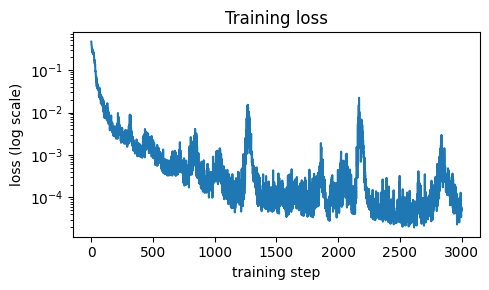

In [2]:
model, losses = train(n_steps=3000, log_every=300)

plt.figure(figsize=(5,3))
plt.plot(losses)
plt.yscale("log")
plt.xlabel("training step")
plt.ylabel("loss (log scale)")
plt.title("Training loss")
plt.tight_layout()
plt.show()

## Simulation

On fait tourner le modèle entraîné sur de nouvelles séquences et on sauvegarde les trajectoires de l'état caché h_t — c'est ce nuage de points qui alimentera `src/manifold` ensuite.

In [3]:
hidden_states, theta = simulate(n_sequences=200, seq_len=200)
print("hidden_states shape:", hidden_states.shape)  # (n_sequences, seq_len, hidden_size)
print("theta shape:", theta.shape)

saved 200 trajectories of length 200 to /home/claude/ProjMa2/data/simulated/head_direction_trajectories.npz
hidden_states shape: torch.Size([200, 200, 64])
hidden_states shape: (200, 200, 64)
theta shape: (200, 200)


## Vérification : l'angle est-il bien encodé dans l'état caché ?

On projette les points en PCA et on les colore par l'angle réel (`theta`). S'attendre à une courbe/anneau lisse avec un dégradé de couleur continu — pas de couleurs qui sautent brutalement d'un point à son voisin.

variance expliquée (3 premières PC): [0.7710494  0.08410335 0.07582885]


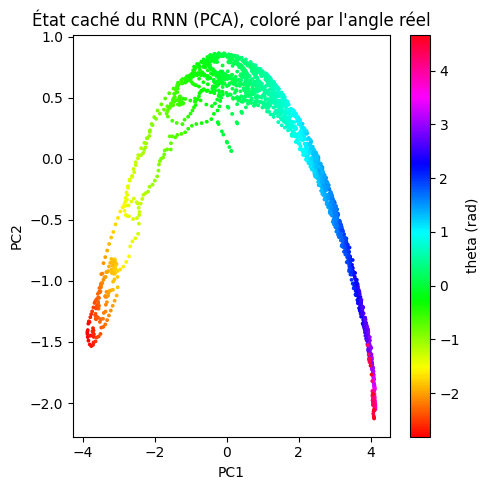

In [4]:
h_flat = hidden_states.reshape(-1, hidden_states.shape[-1])
theta_flat = theta.reshape(-1)

pca = PCA(n_components=3)
h_pca = pca.fit_transform(h_flat)
print("variance expliquée (3 premières PC):", pca.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(5, 5))
sc = ax.scatter(h_pca[:2000, 0], h_pca[:2000, 1], c=theta_flat[:2000], cmap="hsv", s=3)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("État caché du RNN (PCA), coloré par l'angle réel")
plt.colorbar(sc, label="theta (rad)")
plt.tight_layout()
plt.show()

## Sanity check qualitatif : une trajectoire, vitesse vs angle prédit/vrai

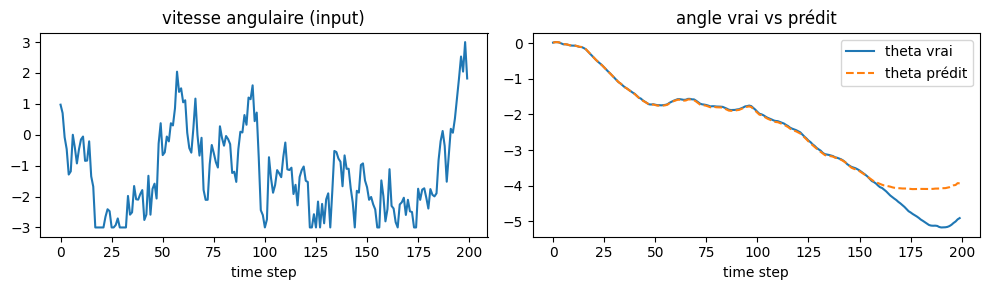

In [5]:
import torch

velocity, target, theta_check = generate_batch(batch_size=1, seq_len=200, seed=7)
with torch.no_grad():
    pred, _ = model(velocity)

t = range(200)
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(t, velocity[0, :, 0].numpy())
axes[0].set_title("vitesse angulaire (input)")
axes[0].set_xlabel("time step")

axes[1].plot(t, theta_check[0].numpy(), label="theta vrai")
theta_pred = torch.atan2(pred[0, :, 1], pred[0, :, 0]).numpy()
axes[1].plot(t, np.unwrap(theta_pred), "--", label="theta prédit")
axes[1].set_title("angle vrai vs prédit")
axes[1].set_xlabel("time step")
axes[1].legend()
plt.tight_layout()
plt.show()